In [77]:
from matplotlib.pylab import plt
import numpy as np
import cv2

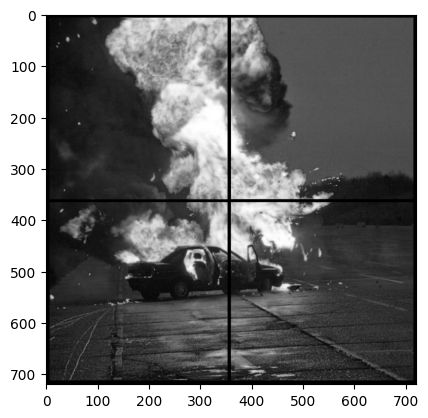

In [78]:
meledak = plt.imread('Assets/meledak.png')
aktivis = cv2.cvtColor(asset, cv2.COLOR_BGR2GRAY)
plt.imshow(aktivis, cmap = 'gray')

(720, 720, 3)
(355, 345)
(355, 350)
(345, 345)
(345, 355)


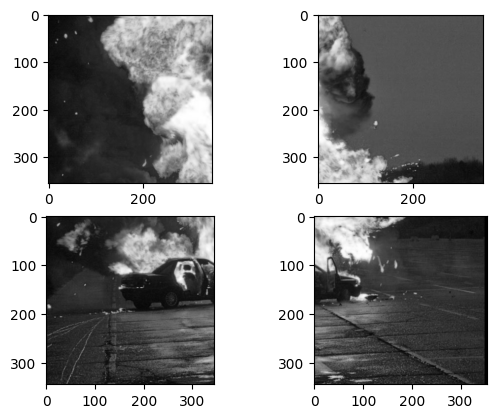

In [210]:
meledak.shape
citra1 = meledak [5:360, 5:350]
citra1 = cv2.cvtColor(citra1, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 1)
plt.imshow(citra1, cmap = 'gray')

citra2 = meledak [5:360, 360:710]
citra2 = cv2.cvtColor(citra2, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 2)
plt.imshow(citra2, cmap = 'gray')

citra3 = meledak [365:710, 5:350]
citra3 = cv2.cvtColor(citra3, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 3)
plt.imshow(citra3, cmap = 'gray')

citra4 = meledak [365:710, 365:720]
citra4 = cv2.cvtColor(citra4, cv2.COLOR_BGR2GRAY)
plt.subplot(2, 2, 4)
plt.imshow(citra4, cmap = 'gray')
print(meledak.shape)
print(citra1.shape)
print(citra2.shape)
print(citra3.shape)
print(citra4.shape)
plt.show()

In [199]:
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

# Tipe c: penyatuan sumbu vertikal
def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

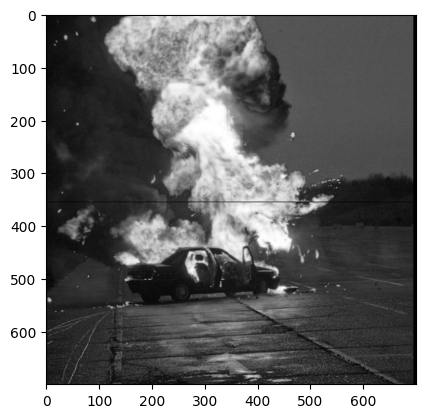

In [211]:
merger1 = fungsi_dua_b (citra1, citra2)
merger2 = fungsi_dua_b (citra3, citra4)
mergered = fungsi_dua_c (merger1, merger2)

plt.imshow(mergered, cmap='gray')
plt.show()

In [158]:
def ekualisasi(citra): 
    height, width = citra.shape 
 
    # 1. Hitung histogram citra
    hist = np.zeros(256, dtype=int) 
    for i in range(height):
        for j in range(width):
            pixel_value = citra[i, j]
            hist[pixel_value] += 1
 
    # 2. Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0] 
    for k in range(1, 256):
        cdf[k] = cdf[k-1] + hist[k]
 
    # 3. Normalisasi CDF ke rentang 0-255
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8) 
 
    # 4. Terapkan hasil normalisasi ke setiap pixel
    hasil = np.zeros_like(citra, dtype=np.uint8) 
    for i in range(height):
        for j in range(width):
            # Nilai pixel lama menjadi index untuk mengambil nilai baru dari cdf_normal
            hasil[i, j] = cdf_normal[citra[i, j]]
 
    return hasil

In [ ]:
equal = ekualisasi(mergered * 255).astype(np.uint8)

plt.imshow(equal, cmap='gray')
plt.axis('off')
plt.title("Citra Hasil Ekualisasi")
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

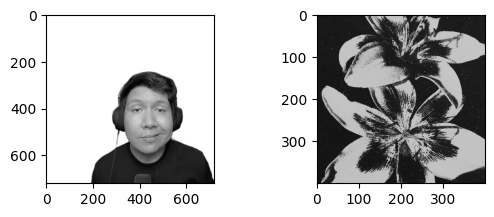

In [153]:
windut = plt.imread('Assets/Windut.png')
windut = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)

bunga = plt.imread('Assets/Bunga.png')

plt.subplot(2, 2, 1)
plt.imshow(windut, cmap = 'gray')

plt.subplot(2, 2, 2)
plt.imshow(bunga, cmap = 'gray')

In [154]:
def spesifikasi_histogram(citra_asal, citra_target): 
    # 1. Hitung histogram citra asal
    hist_asal = np.zeros(256, dtype=int) 
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1
 
    # 2. Hitung histogram citra target
    hist_target = np.zeros(256, dtype=int) 
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    # 3. Hitung CDF (Cumulative Distribution Function)
    for k in range(1, 256):
        cdf_asal[k] = cdf_asal[k-1] + hist_asal[k]
        cdf_target[k] = cdf_target[k-1] + hist_target[k]
 
    # Normalisasi CDF agar rentangnya 0.0 sampai 1.0
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    # 4. Mapping Histogram (Mencari selisih CDF terkecil)
    map_hist = np.zeros(256, dtype=np.uint8) 
    for i in range(256):
        # Cari nilai j di CDF target yang paling dekat dengan nilai CDF asal[i]
        selisih = np.abs(cdf_asal[i] - cdf_target)
        j_terdekat = np.argmin(selisih)
        map_hist[i] = j_terdekat
 
    # 5. Terapkan hasil mapping ke citra asal
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]
 
    return hasil 

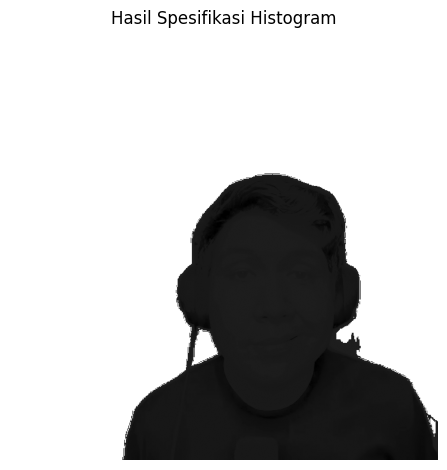

In [ ]:
hasil_spesifikasi = spesifikasi_histogram((windut* 255).astype(np.uint8), (bunga* 255).astype(np.uint8) )

# Tampilan Hasil Spesifikasi
plt.subplot(1, 1, 1)
plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title("Hasil Spesifikasi Histogram")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def buat_hist(citra): 
    histogram = [0] * 255
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 
 

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (256,) and arg 1 with shape (255,).

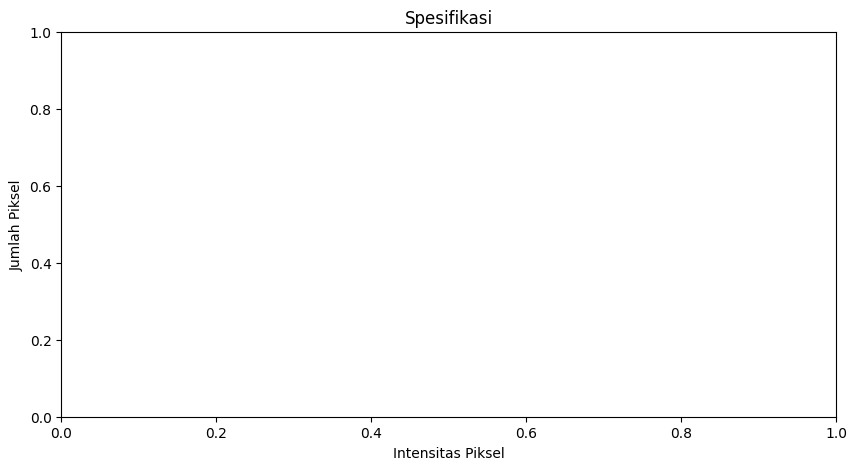

In [ ]:
hist_data = buat_hist(hasil_spesifikasi)
plot_histogram(hist_data, "Spesifikasi", "red")